In [ ]:
! pip install opencxr

  Preparing metadata (setup.py) ... done
INFO: pip is looking at multiple versions of opencxr to determine which version is compatible with other requirements. This could take a while.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 98.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.1/58.1 kB 5.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.6/85.6 kB 8.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.6/52.6 MB 51.4 MB/s eta 0:00:00
  Created wheel for wget: filename=wget-3.2-py3-none-any.whl size=9655 sha256=df4557d9a97e8ca39aa92f66f2ce2a5d3398e28a05824215ee237889a5042ad9
  Stored in directory: /root/.cache/pip/wheels/01/46/3b/e29ffbe4ebe614ff224bad40fc6a5773a67a163251585a13a9
Successfully built wget


### Muntatge de Google Drive a Colab
Aquesta instrucció connecta el  **Google Drive** amb el notebook de **Google Colab**, deixant-lo accessible a la ruta:

`/content/drive`




In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!mkdir /content/images_mha
!cp "/content/drive/MyDrive/ML/DATASETS/NODE21/proccessed_data/images/"* /content/images_mha/


^C


### Definició de rutes del dataset (NODE21)
Aquest bloc defineix la **ruta base** del dataset preprocessat i construeix:

- `PATH_IMAGES`: carpeta on hi ha les imatges (`/images`)
- `PATH_METADATA`: fitxer CSV amb les anotacions (`metadata.csv`)

Finalment, imprimeix les dues rutes per comprovar que són correctes.


In [ ]:
BASE_PATH = "/content/drive/MyDrive/ML/DATASETS/NODE21/proccessed_data"

PATH_IMAGES = f"{BASE_PATH}/images"
PATH_METADATA = f"{BASE_PATH}/metadata.csv"

print(PATH_IMAGES)
print(PATH_METADATA)

/content/drive/MyDrive/ML/DATASETS/NODE21/proccessed_data/images
/content/drive/MyDrive/ML/DATASETS/NODE21/proccessed_data/metadata.csv


### Càrrega del CSV i creació de la ruta completa d’imatge
Aquest codi llegeix el fitxer `metadata.csv` dins un DataFrame (`df`) i crea una nova columna `file_path` amb la **ruta completa** de cada imatge (unint `PATH_IMAGES` + `img_name`).

Finalment mostra les primeres files (`df.head()`) per verificar que les rutes s’han generat bé.


In [ ]:
import pandas as pd
import os

df = pd.read_csv(PATH_METADATA)

df["file_path"] = df["img_name"].apply(
    lambda x: os.path.join(PATH_IMAGES, x)
)

df.head()



,Unnamed: 0,height,img_name,label,width,x,y,file_path
0,0,94,n0239.mha,1,92,776,579,/content/drive/MyDrive/ML/DATASETS/NODE21/proc...
1,1,40,n0342.mha,1,27,223,642,/content/drive/MyDrive/ML/DATASETS/NODE21/proc...
2,2,111,n0996.mha,1,159,687,310,/content/drive/MyDrive/ML/DATASETS/NODE21/proc...
3,3,84,n0418.mha,1,81,343,510,/content/drive/MyDrive/ML/DATASETS/NODE21/proc...
4,4,69,n0538.mha,1,62,599,645,/content/drive/MyDrive/ML/DATASETS/NODE21/proc...


In [ ]:
!ls "/content/drive/MyDrive/ML/DATASETS/NODE21/proccessed_data"

images	metadata.csv  simulated_metadata.csv


### Correcció d’orientació NODE21
Aquesta funció reorienta la imatge aplicant una **rotació de 90° (3 cops)** i un **mirall horitzontal**, per deixar-la amb la mateixa orientació correcta que s’utilitza en el preprocessat del dataset NODE21.


In [ ]:
def fix_node21_orientation(img):
    img = np.rot90(img, k=3)
    img = np.fliplr(img)
    return img

### Visualització d’una imatge MHA (NODE21) amb orientació corregida
Aquest codi **carrega una imatge** del dataset a partir del seu `file_path`, li aplica la funció `fix_node21_orientation()` per **corregir l’orientació**, i finalment la **mostra amb Matplotlib** en escala de grisos per verificar visualment que es veu bé.


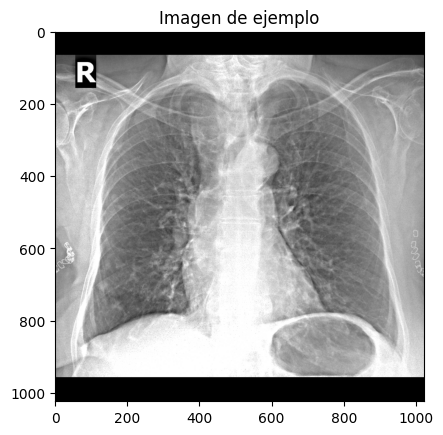

In [ ]:
from opencxr.utils.file_io import read_file
import numpy as np
import matplotlib.pyplot as plt

sample_path = df["file_path"].iloc[1001]
img_np, spacing, _ = read_file(sample_path)
img_np = fix_node21_orientation(img_np)

plt.imshow(img_np, cmap="gray")
plt.title("Imagen de ejemplo")
plt.axis("on")
plt.show()

### Comprovació d’imatges inexistents (missing files)
Aquest fragment **detecta quines files del metadata apunten a una ruta que no existeix** al disc.  
Crea un DataFrame `missing` amb les entrades que falten i imprimeix **quantes imatges no s’han trobat**, mostrant-ne també les primeres amb `head()`.


In [ ]:
missing = df[~df["file_path"].apply(os.path.exists)]
print("Imágenes que faltan:", len(missing))
missing.head()

Imágenes que faltan: 0


,Unnamed: 0,height,img_name,label,width,x,y,file_path


### Dataset de classificació CXR (carrega segura + preprocessat bàsic)
Defineix un `Dataset` per a classificació que **filtra rutes inexistents** i, per cada mostra, llegeix la imatge `.mha`, la **normalitza**, la **redimensiona a 224×224** i la retorna com a tensor amb **1 canal** juntament amb la seva etiqueta (`label`).  
Si hi ha algun problema (fitxer no existeix o error de lectura), retorna `{"error": True}` per evitar que el procés falli.

### `custom_collate`: batch robust (ignora errors)
Funció de *collate* que **elimina mostres amb error** abans de crear el batch.  
Si el batch queda buit retorna `None`, i si no, fa `stack` de les imatges i etiquetes per obtenir tensors finals `images` i `labels` llestos per entrenar.


In [ ]:
import cv2
from torch.utils.data import Dataset
import torch
import numpy as np
import os

class CXRClassificationDataset(Dataset):
    def __init__(self, df):
        # Filtrar solo rutas válidas
        self.df = df[df["file_path"].apply(os.path.exists)].reset_index(drop=True)

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img_path = row["file_path"]

        # Por seguridad si no existe
        if not os.path.exists(img_path):
            return {"error": True}

        try:
            img_np, _, _ = read_file(img_path)
        except Exception:
            return {"error": True}

        # Normalizar
        img = img_np.astype(np.float32)
        img = (img - img.min()) / (img.max() - img.min())

        # --- REESCALADO A 224×224 ---
        img = cv2.resize(img, (224, 224))

        # Añadir canal
        img = np.expand_dims(img, axis=0)

        return {
            "error": False,
            "image": torch.tensor(img, dtype=torch.float32),
            "label": torch.tensor(row["label"], dtype=torch.long)
        }


def custom_collate(batch):
    # Filtrar elementos con error=True
    batch = [item for item in batch if (item is not None and not item.get("error", False))]

    # Si el batch está vacío, devolvemos None
    if len(batch) == 0:
        return None

    # Stack de imágenes
    images = torch.stack([item["image"] for item in batch])
    labels = torch.stack([item["label"] for item in batch])

    return images, labels




### CNN simple (des de zero) per classificació binària
Defineix una xarxa convolucional bàsica amb **3 blocs Conv + ReLU + MaxPool** per extreure característiques de les imatges 1-canal.  
Després fa un **Flatten + capes fully-connected** per acabar predint **2 classes** (nòdul / no nòdul).

### Preparació de `train_loader` i `test_loader`
Divideix el `df` en **train (80%)** i **test (20%)**, crea els `Dataset` i construeix els `DataLoader` amb batch de 16.  
S’utilitza `custom_collate` per **ignorar mostres amb error** durant la càrrega.

### Entrenament del model
Entrena la CNN durant **10 èpoques** amb:
- **CrossEntropyLoss** (classificació multiclasse, aquí 2 classes)
- **Adam** amb `lr=1e-3`

A cada batch calcula la pèrdua, fa `backpropagation`, actualitza pesos i acumula:
- **loss mitjana per època**
- **accuracy per època**

### Gràfiques d’evolució
Dibuixa dues corbes per veure si el model aprèn:
- **Loss vs època**
- **Accuracy vs època**

### Avaluació final en test
Posa el model en mode `eval()` i calcula l’**accuracy en el conjunt de test** sense entrenar (`torch.no_grad()`), obtenint el rendiment final.


Tamaño train: 4179
Tamaño test: 1045


Época 1/10: 100%|██████████| 262/262 [07:41<00:00,  1.76s/it, loss=0.522]


Epoch 1: Loss=0.5966  Accuracy=0.7169


Época 2/10: 100%|██████████| 262/262 [03:27<00:00,  1.27it/s, loss=0.46]


Epoch 2: Loss=0.5316  Accuracy=0.7222


...

Epoch 8: Loss=0.4222  Accuracy=0.8007


Época 9/10: 100%|██████████| 262/262 [02:44<00:00,  1.59it/s, loss=0.408]


Epoch 9: Loss=0.4001  Accuracy=0.8069


Época 10/10: 100%|██████████| 262/262 [03:54<00:00,  1.12it/s, loss=0.277]


Epoch 10: Loss=0.3750  Accuracy=0.8227


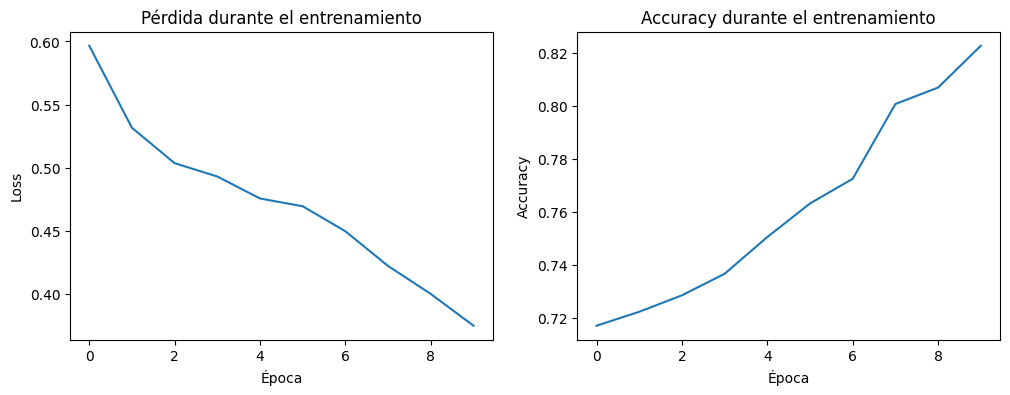

Accuracy en test: 0.7904


In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np
from tqdm import tqdm

# ======================================================
# 1. DEFINICIÓN DE LA CNN SIMPLE (DESDE CERO)
# ======================================================
class SimpleCNN(nn.Module):
    def __init__(self):
        super(SimpleCNN, self).__init__()

        self.conv_layers = nn.Sequential(
            nn.Conv2d(1, 16, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),  # salida: 16 x 112 x 112

            nn.Conv2d(16, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),  # salida: 32 x 56 x 56

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),  # salida: 64 x 28 x 28
        )

        self.fc_layers = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64 * 28 * 28, 128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, 2)   # Clasificación binaria
        )

    def forward(self, x):
        x = self.conv_layers(x)
        x = self.fc_layers(x)
        return x


# ======================================================
# 2. PREPARAR TRAINLOADER Y TESTLOADER
# ======================================================
# Divide tus datos (80% train, 20% test)
from sklearn.model_selection import train_test_split

train_df, test_df = train_test_split(df, test_size=0.2, random_state=42)

train_dataset = CXRClassificationDataset(train_df)
test_dataset = CXRClassificationDataset(test_df)

train_loader = DataLoader(
    train_dataset,
    batch_size=16,
    shuffle=True,
    collate_fn=custom_collate
)

test_loader = DataLoader(
    test_dataset,
    batch_size=16,
    shuffle=False,
    collate_fn=custom_collate
)

print("Tamaño train:", len(train_dataset))
print("Tamaño test:", len(test_dataset))


# ======================================================
# 3. ENTRENAMIENTO DEL MODELO
# ======================================================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = SimpleCNN().to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)

epochs = 10  
train_losses = []
train_accs = []

for epoch in range(epochs):
    model.train()
    running_loss = 0
    correct = 0
    total = 0

    loop = tqdm(train_loader, desc=f"Época {epoch+1}/{epochs}")

    for images, labels in loop:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        # Estadísticas
        running_loss += loss.item()
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

        loop.set_postfix(loss=loss.item())

    epoch_loss = running_loss / len(train_loader)
    epoch_acc = correct / total

    train_losses.append(epoch_loss)
    train_accs.append(epoch_acc)

    print(f"Epoch {epoch+1}: Loss={epoch_loss:.4f}  Accuracy={epoch_acc:.4f}")


# ======================================================
# 4. GRÁFICAS DE ENTRENAMIENTO
# ======================================================
plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
plt.plot(train_losses, label="Loss")
plt.title("Pérdida durante el entrenamiento")
plt.xlabel("Época")
plt.ylabel("Loss")

plt.subplot(1,2,2)
plt.plot(train_accs, label="Accuracy")
plt.title("Accuracy durante el entrenamiento")
plt.xlabel("Época")
plt.ylabel("Accuracy")

plt.show()


# ======================================================
# 5. EVALUACIÓN EN TEST
# ======================================================
model.eval()
correct = 0
total = 0

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

test_accuracy = correct / total
print(f"Accuracy en test: {test_accuracy:.4f}")


### Avaluació del model

- Model en mode **avaluació** i sense gradients.
- Es generen prediccions sobre el **conjunt de test**.
- Es comparen prediccions i etiquetes reals.
- Es calcula el **classification report** i la **matriu de confusió**.


In [ ]:
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.metrics import precision_score, recall_score, f1_score
import numpy as np
import torch

model.eval()
all_labels = []
all_preds = []

with torch.no_grad():
    for batch in test_loader:
        if batch is None:
            continue

        images, labels = batch
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)
        _, predicted = torch.max(outputs, 1)

        all_labels.extend(labels.cpu().numpy())
        all_preds.extend(predicted.cpu().numpy())

all_labels = np.array(all_labels)
all_preds = np.array(all_preds)

# ======= MÉTRICAS =======
print("Classification Report:")
print(classification_report(all_labels, all_preds, digits=4))

cm = confusion_matrix(all_labels, all_preds)



Classification Report:
              precision    recall  f1-score   support

           0     0.8519    0.8484    0.8501       732
           1     0.6487    0.6550    0.6518       313

    accuracy                         0.7904      1045
   macro avg     0.7503    0.7517    0.7510      1045
weighted avg     0.7910    0.7904    0.7907      1045



In [ ]:
!ls "/content/drive/MyDrive/ML/DATASETS/NODE21/proccessed_data/images"


processed_image.zip


In [ ]:
!unzip "/content/drive/MyDrive/ML/DATASETS/NODE21/proccessed_data/images/processed_image.zip" -d "/content/drive/MyDrive/ML/DATASETS/NODE21/proccessed_data/images"


Archive:  /content/drive/MyDrive/ML/DATASETS/NODE21/proccessed_data/images/processed_image.zip
  inflating: /content/drive/MyDrive/ML/DATASETS/NODE21/proccessed_data/images/n1125.mha  
  inflating: /content/drive/MyDrive/ML/DATASETS/NODE21/proccessed_data/images/n1126.mha  
  inflating: /content/drive/MyDrive/ML/DATASETS/NODE21/proccessed_data/images/n1127.mha  
  inflating: /content/drive/MyDrive/ML/DATASETS/NODE21/proccessed_data/images/n1128.mha  
  inflating: /content/drive/MyDrive/ML/DATASETS/NODE21/proccessed_data/images/n1129.mha  
  inflating: /content/drive/MyDrive/ML/DATASETS/NODE21/proccessed_data/images/n1130.mha  
  inflating: /content/drive/MyDrive/ML/DATASETS/NODE21/proccessed_data/images/n1131.mha  
  inflating: /content/drive/MyDrive/ML/DATASETS/NODE21/proccessed_data/images/n1132.mha  
  inflating: /content/drive/MyDrive/ML/DATASETS/NODE21/proccessed_data/images/n1133.mha  
  inflating: /content/drive/MyDrive/ML/DATASETS/NODE21/proccessed_data/images/n1134.mha  
  inf

In [ ]:
!unzip "/content/drive/MyDrive/ML/DATASETS/NODE21/original_data/images/original_data.zip" -d "/content/drive/MyDrive/ML/DATASETS/NODE21/original_data/images"

Archive:  /content/drive/MyDrive/ML/DATASETS/NODE21/original_data/images/original_data.zip
   creating: /content/drive/MyDrive/ML/DATASETS/NODE21/original_data/images/original_data/
  inflating: /content/drive/MyDrive/ML/DATASETS/NODE21/original_data/images/original_data/filenames_orig_and_new.csv  
   creating: /content/drive/MyDrive/ML/DATASETS/NODE21/original_data/images/original_data/images/
  inflating: /content/drive/MyDrive/ML/DATASETS/NODE21/original_data/images/original_data/images/c0001.mha  
  inflating: /content/drive/MyDrive/ML/DATASETS/NODE21/original_data/images/original_data/images/c0002.mha  
  inflating: /content/drive/MyDrive/ML/DATASETS/NODE21/original_data/images/original_data/images/c0003.mha  
  inflating: /content/drive/MyDrive/ML/DATASETS/NODE21/original_data/images/original_data/images/c0004.mha  
  inflating: /content/drive/MyDrive/ML/DATASETS/NODE21/original_data/images/original_data/images/c0005.mha  
  inflating: /content/drive/MyDrive/ML/DATASETS/NODE21/o

### Flux general del codi

- Importació de **llibreries** i selecció de **CPU/GPU**.
- Càrrega de **metadades** i validació de rutes d’imatges.
- Definició d’un **Dataset** per a imatges MHA (normalització i redimensionat).
- **Collate personalitzat** per descartar errors de lectura.
- Divisió **train / test (80/20)** i creació de DataLoaders.
- **Transfer learning amb ResNet18** (pesos ImageNet, backbone congelat).
- Definició de **loss** i **optimitzador**.
- **Entrenament** del model durant diverses èpoques.
- **Avaluació** amb classification report i **matriu de confusió**.


In [ ]:
# ============================================
# 1. IMPORTS
# ============================================
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import models
import numpy as np
import cv2
import os
from tqdm import tqdm
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
from opencxr.utils.file_io import read_file  


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)


# ============================================
# 2. CARGAR METADATA
# ============================================
BASE_PATH = "/content/drive/MyDrive/ML/DATASETS/NODE21/proccessed_data"
PATH_IMAGES = f"{BASE_PATH}/images"
PATH_METADATA = f"{BASE_PATH}/metadata.csv"

import pandas as pd
df = pd.read_csv(PATH_METADATA)

# Crear ruta completa
df["file_path"] = df["img_name"].apply(lambda x: os.path.join(PATH_IMAGES, x))

# Filtrar rutas que existen
df = df[df["file_path"].apply(os.path.exists)].reset_index(drop=True)

print("Total imágenes MHA válidas:", len(df))


# ============================================
# 3. DATASET MHA 
# ============================================
class CXRClassificationDataset(torch.utils.data.Dataset):
    def __init__(self, df):
        self.df = df[df["file_path"].apply(os.path.exists)].reset_index(drop=True)

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img_path = row["file_path"]

        if not os.path.exists(img_path):
            return {"error": True}

        try:
            img_np, _, _ = read_file(img_path)
        except:
            return {"error": True}

        # Normalizar [0,1]
        img = img_np.astype(np.float32)
        img = (img - img.min()) / (img.max() - img.min())

        # Redimensionar a 224x224
        img = cv2.resize(img, (224, 224))

        # Añadir canal -> (1,H,W)
        img = np.expand_dims(img, axis=0)

        # Convertir a 3 canales -> (3,H,W)
        img = np.repeat(img, 3, axis=0)

        return {
            "error": False,
            "image": torch.tensor(img, dtype=torch.float32),
            "label": torch.tensor(row["label"], dtype=torch.long)
        }


# ============================================
# 4. COLLATE 
# ============================================
def custom_collate(batch):
    batch = [item for item in batch if (item is not None and not item.get("error", False))]
    if len(batch) == 0:
        return None

    images = torch.stack([item["image"] for item in batch])
    labels = torch.stack([item["label"] for item in batch])
    return images, labels


# ============================================
# 5. TRAIN / TEST SPLIT
# ============================================
train_df, test_df = train_test_split(df, test_size=0.2, random_state=42)

train_dataset = CXRClassificationDataset(train_df)
test_dataset = CXRClassificationDataset(test_df)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True,
                          num_workers=2, pin_memory=True, collate_fn=custom_collate)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False,
                         num_workers=2, pin_memory=True, collate_fn=custom_collate)

print("Train:", len(train_dataset), " Test:", len(test_dataset))


# ============================================
# 6. RESNET18 TRANSFER LEARNING
# ============================================
model = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)

# Congelar todo
for param in model.parameters():
    param.requires_grad = False

# Cambiar la última capa a 2 clases
num_features = model.fc.in_features
model.fc = nn.Linear(num_features, 2)

model = model.to(device)


# ============================================
# 7. OPTIMIZADOR Y LOSS
# ============================================
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.fc.parameters(), lr=1e-3)


# ============================================
# 8. ENTRENAMIENTO
# ============================================
epochs = 10
model.train()

for epoch in range(epochs):
    running_loss = 0
    correct = 0
    total = 0

    loop = tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs}")

    for batch in loop:
        if batch is None:
            continue

        images, labels = batch
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        running_loss += loss.item()

        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

        loop.set_postfix(loss=loss.item())

    print(f"Epoch {epoch+1}: Loss={running_loss/len(train_loader):.4f}, Acc={correct/total:.4f}")


# ============================================
# 9. EVALUACIÓN
# ============================================
model.eval()
all_labels = []
all_preds = []

with torch.no_grad():
    for batch in test_loader:
        if batch is None:
            continue

        images, labels = batch
        images, labels = images.to(device), labels.to(device)

        outputs = model(images)
        _, predicted = torch.max(outputs, 1)

        all_labels.extend(labels.cpu().numpy())
        all_preds.extend(predicted.cpu().numpy())

print("Classification Report:")
print(classification_report(all_labels, all_preds, digits=4))

cm = confusion_matrix(all_labels, all_preds)
print(cm)


Device: cuda
Total imágenes MHA válidas: 5224
Train: 4179  Test: 1045
Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 239MB/s]
Epoch 1/10: 100%|██████████| 131/131 [02:20<00:00,  1.07s/it, loss=0.383]


Epoch 1: Loss=0.5250, Acc=0.7351


Epoch 2/10: 100%|██████████| 131/131 [01:52<00:00,  1.17it/s, loss=0.522]


Epoch 2: Loss=0.4546, Acc=0.7741


...

Epoch 9/10: 100%|██████████| 131/131 [01:52<00:00,  1.16it/s, loss=0.468]


Epoch 9: Loss=0.3607, Acc=0.8373


Epoch 10/10: 100%|██████████| 131/131 [01:53<00:00,  1.15it/s, loss=0.438]

Epoch 10: Loss=0.3637, Acc=0.8387


Classification Report:
              precision    recall  f1-score   support

           0     0.8048    0.9631    0.8769       732
           1     0.8402    0.4537    0.5892       313

    accuracy                         0.8105      1045
   macro avg     0.8225    0.7084    0.7330      1045
weighted avg     0.8154    0.8105    0.7907      1045

[[705  27]
 [171 142]]


### Flux del codi (DenseNet121)

- Importació de llibreries i selecció de **CPU/GPU**.
- Càrrega de **metadades** i filtratge d’imatges existents.
- Definició d’un **Dataset** per a imatges MHA (normalització i resize).
- **Collate personalitzat** per ignorar errors de lectura.
- Divisió **train/test (80/20)** i creació de DataLoaders.
- **Transfer learning amb DenseNet121** (pesos ImageNet, backbone congelat).
- Definició de **loss** i **optimitzador**.
- **Entrenament** del classificador final.
- **Avaluació** amb classification report i **matriu de confusió**.


In [ ]:
# ============================================
# 1. IMPORTS
# ============================================
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import models
import cv2
import numpy as np
import os
from torch.utils.data import Dataset, DataLoader
from tqdm import tqdm
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
import pandas as pd
from opencxr.utils.file_io import read_file

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)


# ============================================
# 2. CARGAR METADATA
# ============================================
BASE_PATH = "/content/drive/MyDrive/ML/DATASETS/NODE21/proccessed_data"
PATH_IMAGES = f"{BASE_PATH}/images"
PATH_METADATA = f"{BASE_PATH}/metadata.csv"

df = pd.read_csv(PATH_METADATA)
df["file_path"] = df["img_name"].apply(lambda x: os.path.join(PATH_IMAGES, x))

# Filtrar solo los que existen
df = df[df["file_path"].apply(os.path.exists)].reset_index(drop=True)
print("Total imágenes válidas:", len(df))


# ============================================
# 3. DATASET PARA IMÁGENES .MHA
# ============================================
class CXRClassificationDataset(Dataset):
    def __init__(self, df):
        self.df = df[df["file_path"].apply(os.path.exists)].reset_index(drop=True)

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img_path = row["file_path"]

        if not os.path.exists(img_path):
            return {"error": True}

        try:
            img_np, _, _ = read_file(img_path)
        except:
            return {"error": True}

        # Normalizar
        img = img_np.astype(np.float32)
        img = (img - img.min()) / (img.max() - img.min())

        # Resize a 224×224
        img = cv2.resize(img, (224, 224))

        # Añadir canal (1,H,W)
        img = np.expand_dims(img, axis=0)

        # Repetir a 3 canales → (3,H,W)
        img = np.repeat(img, 3, axis=0)

        return {
            "error": False,
            "image": torch.tensor(img, dtype=torch.float32),
            "label": torch.tensor(row["label"], dtype=torch.long)
        }


# ============================================
# 4. COLLATE
# ============================================
def custom_collate(batch):
    batch = [item for item in batch if (item is not None and not item.get("error", False))]
    if len(batch) == 0:
        return None

    images = torch.stack([item["image"] for item in batch])
    labels = torch.stack([item["label"] for item in batch])
    return images, labels


# ============================================
# 5. TRAIN/TEST SPLIT + DATALOADERS
# ============================================
train_df, test_df = train_test_split(df, test_size=0.2, random_state=42)

train_dataset = CXRClassificationDataset(train_df)
test_dataset = CXRClassificationDataset(test_df)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True,
                          num_workers=2, pin_memory=True, collate_fn=custom_collate)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False,
                         num_workers=2, pin_memory=True, collate_fn=custom_collate)

print("Train:", len(train_dataset), " Test:", len(test_dataset))


# ============================================
# 6. DEFINIR DENSENET121 (TRANSFER LEARNING)
# ============================================
model = models.densenet121(weights=models.DenseNet121_Weights.IMAGENET1K_V1)

# Congelar TODAS las capas menos el clasificador
for param in model.parameters():
    param.requires_grad = False

# Reemplazar el clasificador final para 2 clases
num_features = model.classifier.in_features
model.classifier = nn.Linear(num_features, 2)

model = model.to(device)


# ============================================
# 7. OPTIMIZADOR Y LOSS
# ============================================
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.classifier.parameters(), lr=1e-3)


# ============================================
# 8. ENTRENAMIENTO
# ============================================
epochs = 10

for epoch in range(epochs):
    model.train()
    running_loss = 0
    correct = 0
    total = 0

    loop = tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs}")

    for batch in loop:
        if batch is None:
            continue

        images, labels = batch
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)

        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

        loop.set_postfix(loss=loss.item())

    print(f"Epoch {epoch+1}: Loss={running_loss/len(train_loader):.4f}, Acc={correct/total:.4f}")


# ============================================
# 9. EVALUACIÓN
# ============================================
model.eval()
all_labels = []
all_preds = []

with torch.no_grad():
    for batch in test_loader:
        if batch is None:
            continue

        images, labels = batch
        images, labels = images.to(device), labels.to(device)

        outputs = model(images)
        _, predicted = torch.max(outputs, 1)

        all_labels.extend(labels.cpu().numpy())
        all_preds.extend(predicted.cpu().numpy())

print("=== Classification Report ===")
print(classification_report(all_labels, all_preds, digits=4))

cm = confusion_matrix(all_labels, all_preds)
print("=== Confusion Matrix ===")
print(cm)


Device: cuda
Total imágenes válidas: 5224
Train: 4179  Test: 1045
Downloading: "https://download.pytorch.org/models/densenet121-a639ec97.pth" to /root/.cache/torch/hub/checkpoints/densenet121-a639ec97.pth


100%|██████████| 30.8M/30.8M [00:00<00:00, 222MB/s]
Epoch 1/10: 100%|██████████| 131/131 [02:24<00:00,  1.10s/it, loss=0.395]


Epoch 1: Loss=0.5052, Acc=0.7550


Epoch 2/10: 100%|██████████| 131/131 [01:50<00:00,  1.19it/s, loss=0.538]


Epoch 2: Loss=0.4152, Acc=0.8057


...

Epoch 9/10: 100%|██████████| 131/131 [01:53<00:00,  1.15it/s, loss=0.224]


Epoch 9: Loss=0.3154, Acc=0.8641


Epoch 10/10: 100%|██████████| 131/131 [01:52<00:00,  1.16it/s, loss=0.276]

Epoch 10: Loss=0.3036, Acc=0.8729


=== Classification Report ===
              precision    recall  f1-score   support

           0     0.8781    0.9057    0.8917       732
           1     0.7621    0.7061    0.7330       313

    accuracy                         0.8459      1045
   macro avg     0.8201    0.8059    0.8124      1045
weighted avg     0.8434    0.8459    0.8442      1045

=== Confusion Matrix ===
[[663  69]
 [ 92 221]]


### Flux del codi (EfficientNet-B0)

- Importació de llibreries i selecció de **CPU/GPU**.
- Càrrega de **metadades** i validació d’imatges existents.
- **Dataset MHA**: normalització, resize a 224×224 i conversió a 3 canals.
- **Collate personalitzat** per descartar errors.
- Divisió **train/test (80/20)** i DataLoaders.
- **Transfer learning amb EfficientNet-B0** (pesos ImageNet, capes congelades).
- Definició de **loss** i **optimitzador**.
- **Entrenament** del classificador final.
- **Avaluació** amb classification report i **matriu de confusió**.


In [ ]:
# ============================================
# 1. IMPORTS
# ============================================
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import models
import cv2
import numpy as np
import os
from torch.utils.data import Dataset, DataLoader
from tqdm import tqdm
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
import pandas as pd
from opencxr.utils.file_io import read_file

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)


# ============================================
# 2. CARGAR METADATA
# ============================================
BASE_PATH = "/content/drive/MyDrive/ML/DATASETS/NODE21/proccessed_data"
PATH_IMAGES = f"{BASE_PATH}/images"
PATH_METADATA = f"{BASE_PATH}/metadata.csv"

df = pd.read_csv(PATH_METADATA)
df["file_path"] = df["img_name"].apply(lambda x: os.path.join(PATH_IMAGES, x))

# Filtrar imágenes que existen
df = df[df["file_path"].apply(os.path.exists)].reset_index(drop=True)
print("Total imágenes válidas:", len(df))


# ============================================
# 3. DATASET PARA IMÁGENES MHA (idéntico a ResNet / DenseNet)
# ============================================
class CXRClassificationDataset(Dataset):
    def __init__(self, df):
        self.df = df[df["file_path"].apply(os.path.exists)].reset_index(drop=True)

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img_path = row["file_path"]

        if not os.path.exists(img_path):
            return {"error": True}

        try:
            img_np, _, _ = read_file(img_path)
        except:
            return {"error": True}

        # Normalizar
        img = img_np.astype(np.float32)
        img = (img - img.min()) / (img.max() - img.min())

        # Resize 224×224
        img = cv2.resize(img, (224, 224))

        # Añadir canal (1,H,W)
        img = np.expand_dims(img, axis=0)

        # EfficientNet requiere 3 canales
        img = np.repeat(img, 3, axis=0)

        return {
            "error": False,
            "image": torch.tensor(img, dtype=torch.float32),
            "label": torch.tensor(row["label"], dtype=torch.long)
        }


# ============================================
# 4. COLLATE
# ============================================
def custom_collate(batch):
    batch = [item for item in batch if (item is not None and not item.get("error", False))]
    if len(batch) == 0:
        return None

    images = torch.stack([item["image"] for item in batch])
    labels = torch.stack([item["label"] for item in batch])
    return images, labels


# ============================================
# 5. TRAIN/TEST SPLIT + DATALOADERS
# ============================================
train_df, test_df = train_test_split(df, test_size=0.2, random_state=42)

train_dataset = CXRClassificationDataset(train_df)
test_dataset = CXRClassificationDataset(test_df)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True,
                          num_workers=2, pin_memory=True, collate_fn=custom_collate)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False,
                         num_workers=2, pin_memory=True, collate_fn=custom_collate)

print("Train:", len(train_dataset), " Test:", len(test_dataset))


# ============================================
# 6. DEFINIR EFFICIENTNET-B0 (TRANSFER LEARNING)
# ============================================
model = models.efficientnet_b0(weights=models.EfficientNet_B0_Weights.IMAGENET1K_V1)

# Congelamos todas las capas
for param in model.parameters():
    param.requires_grad = False

# Modificar la última capa para 2 clases
num_features = model.classifier[1].in_features
model.classifier[1] = nn.Linear(num_features, 2)

model = model.to(device)


# ============================================
# 7. OPTIMIZADOR Y LOSS
# ============================================
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.classifier.parameters(), lr=1e-3)


# ============================================
# 8. ENTRENAMIENTO
# ============================================
epochs = 10

for epoch in range(epochs):
    model.train()
    running_loss = 0
    correct = 0
    total = 0

    loop = tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs}")

    for batch in loop:
        if batch is None:
            continue

        images, labels = batch
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)

        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

        loop.set_postfix(loss=loss.item())

    print(f"Epoch {epoch+1}: Loss={running_loss/len(train_loader):.4f}, Acc={correct/total:.4f}")


# ============================================
# 9. EVALUACIÓN
# ============================================
model.eval()
all_labels = []
all_preds = []

with torch.no_grad():
    for batch in test_loader:
        if batch is None:
            continue

        images, labels = batch
        images, labels = images.to(device), labels.to(device)

        outputs = model(images)
        _, predicted = torch.max(outputs, 1)

        all_labels.extend(labels.cpu().numpy())
        all_preds.extend(predicted.cpu().numpy())

print("\n=== Classification Report ===")
print(classification_report(all_labels, all_preds, digits=4))

cm = confusion_matrix(all_labels, all_preds)
print("=== Confusion Matrix ===")
print(cm)


Device: cuda
Total imágenes válidas: 5224
Train: 4179  Test: 1045
Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 231MB/s]
Epoch 1/10: 100%|██████████| 131/131 [03:03<00:00,  1.40s/it, loss=0.51]


Epoch 1: Loss=0.4593, Acc=0.7875


Epoch 2/10: 100%|██████████| 131/131 [02:28<00:00,  1.13s/it, loss=0.475]


Epoch 2: Loss=0.3842, Acc=0.8303


...

Epoch 9/10: 100%|██████████| 131/131 [01:50<00:00,  1.18it/s, loss=0.227]


Epoch 9: Loss=0.3146, Acc=0.8660


Epoch 10/10: 100%|██████████| 131/131 [01:49<00:00,  1.19it/s, loss=0.312]

Epoch 10: Loss=0.3191, Acc=0.8626



=== Classification Report ===
              precision    recall  f1-score   support

           0     0.8747    0.9344    0.9036       732
           1     0.8175    0.6869    0.7465       313

    accuracy                         0.8603      1045
   macro avg     0.8461    0.8107    0.8250      1045
weighted avg     0.8576    0.8603    0.8565      1045

=== Confusion Matrix ===
[[684  48]
 [ 98 215]]


### Flux del codi (EfficientNet-B3)

- Importació de llibreries i configuració de **CPU/GPU**.
- Càrrega de **metadades** i filtratge d’imatges vàlides.
- **Dataset MHA**: normalització, resize i conversió a 3 canals.
- **Collate personalitzat** per evitar mostres amb error.
- Divisió **train/test (80/20)** i DataLoaders.
- **Transfer learning amb EfficientNet-B3** (pesos ImageNet, capes congelades).
- Definició de **loss** i **optimitzador**.
- **Entrenament** del classificador final.
- **Avaluació** amb classification report i **matriu de confusió**.


In [ ]:
# ============================================
# 1. IMPORTS
# ============================================
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import models
import cv2
import numpy as np
import os
from torch.utils.data import Dataset, DataLoader
from tqdm import tqdm
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
import pandas as pd
from opencxr.utils.file_io import read_file

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)


# ============================================
# 2. CARGAR METADATA
# ============================================
BASE_PATH = "/content/drive/MyDrive/ML/DATASETS/NODE21/proccessed_data"
PATH_IMAGES = f"{BASE_PATH}/images"
PATH_METADATA = f"{BASE_PATH}/metadata.csv"

df = pd.read_csv(PATH_METADATA)
df["file_path"] = df["img_name"].apply(lambda x: os.path.join(PATH_IMAGES, x))

# Filtrar imágenes que existen
df = df[df["file_path"].apply(os.path.exists)].reset_index(drop=True)
print("Total imágenes válidas:", len(df))


# ============================================
# 3. DATASET MHA (MISMO QUE LOS OTROS MODELOS)
# ============================================
class CXRClassificationDataset(Dataset):
    def __init__(self, df):
        self.df = df[df["file_path"].apply(os.path.exists)].reset_index(drop=True)

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img_path = row["file_path"]

        if not os.path.exists(img_path):
            return {"error": True}

        try:
            img_np, _, _ = read_file(img_path)
        except:
            return {"error": True}

        # Normalizar [0,1]
        img = img_np.astype(np.float32)
        img = (img - img.min()) / (img.max() - img.min())

        # Resize a 224×224 (EfficientNet B3 usa 300×300, pero 224 funciona bien)
        img = cv2.resize(img, (224, 224))

        # Añadir canal → (1,H,W)
        img = np.expand_dims(img, axis=0)

        # Convertir a 3 canales
        img = np.repeat(img, 3, axis=0)

        return {
            "error": False,
            "image": torch.tensor(img, dtype=torch.float32),
            "label": torch.tensor(row["label"], dtype=torch.long)
        }


# ============================================
# 4. COLLATE
# ============================================
def custom_collate(batch):
    batch = [item for item in batch if (item is not None and not item.get("error", False))]
    if len(batch) == 0:
        return None
    images = torch.stack([item["image"] for item in batch])
    labels = torch.stack([item["label"] for item in batch])
    return images, labels


# ============================================
# 5. TRAIN/TEST SPLIT + DATALOADERS
# ============================================
train_df, test_df = train_test_split(df, test_size=0.2, random_state=42)

train_dataset = CXRClassificationDataset(train_df)
test_dataset = CXRClassificationDataset(test_df)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True,
                          num_workers=2, pin_memory=True, collate_fn=custom_collate)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False,
                         num_workers=2, pin_memory=True, collate_fn=custom_collate)

print("Train:", len(train_dataset), " Test:", len(test_dataset))


# ============================================
# 6. EfficientNet-B3 (TRANSFER LEARNING)
# ============================================
model = models.efficientnet_b3(weights=models.EfficientNet_B3_Weights.IMAGENET1K_V1)

# Congelar toda la red salvo la última capa
for param in model.parameters():
    param.requires_grad = False

# Modificar la capa final
num_features = model.classifier[1].in_features
model.classifier[1] = nn.Linear(num_features, 2)   # 2 clases

model = model.to(device)


# ============================================
# 7. OPTIMIZADOR Y LOSS
# ============================================
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.classifier.parameters(), lr=1e-3)


# ============================================
# 8. ENTRENAMIENTO
# ============================================
epochs = 10

for epoch in range(epochs):
    model.train()
    running_loss = 0
    correct = 0
    total = 0

    loop = tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs}")

    for batch in loop:
        if batch is None:
            continue

        images, labels = batch
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)

        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

        # Accuracy entrenamiento
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

        loop.set_postfix(loss=loss.item())

    print(f"Epoch {epoch+1}: Loss={running_loss/len(train_loader):.4f}, Acc={correct/total:.4f}")


# ============================================
# 9. EVALUACIÓN
# ============================================
model.eval()
all_labels = []
all_preds = []

with torch.no_grad():
    for batch in test_loader:
        if batch is None:
            continue

        images, labels = batch
        images, labels = images.to(device), labels.to(device)

        outputs = model(images)
        _, predicted = torch.max(outputs, 1)

        all_labels.extend(labels.cpu().numpy())
        all_preds.extend(predicted.cpu().numpy())

print("\n=== Classification Report EfficientNet-B3 ===")
print(classification_report(all_labels, all_preds, digits=4))

cm = confusion_matrix(all_labels, all_preds)
print("=== Confusion Matrix ===")
print(cm)


Device: cuda
Total imágenes válidas: 5224
Train: 4179  Test: 1045
Downloading: "https://download.pytorch.org/models/efficientnet_b3_rwightman-b3899882.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b3_rwightman-b3899882.pth


100%|██████████| 47.2M/47.2M [00:00<00:00, 147MB/s]
Epoch 1/10: 100%|██████████| 131/131 [02:24<00:00,  1.10s/it, loss=0.521]


Epoch 1: Loss=0.5200, Acc=0.7401


Epoch 2/10: 100%|██████████| 131/131 [01:48<00:00,  1.20it/s, loss=0.369]


Epoch 2: Loss=0.4610, Acc=0.7877


...

Epoch 9/10: 100%|██████████| 131/131 [01:49<00:00,  1.20it/s, loss=0.245]


Epoch 9: Loss=0.4094, Acc=0.8117


Epoch 10/10: 100%|██████████| 131/131 [01:49<00:00,  1.20it/s, loss=0.499]

Epoch 10: Loss=0.4118, Acc=0.8107



=== Classification Report EfficientNet-B3 ===
              precision    recall  f1-score   support

           0     0.8358    0.9317    0.8811       732
           1     0.7817    0.5719    0.6605       313

    accuracy                         0.8239      1045
   macro avg     0.8087    0.7518    0.7708      1045
weighted avg     0.8196    0.8239    0.8151      1045

=== Confusion Matrix ===
[[682  50]
 [134 179]]


### Flux del codi (DenseNet-169)

- Importació de llibreries i configuració de **CPU/GPU**.
- Càrrega de **metadades** i validació d’imatges existents.
- **Dataset MHA**: normalització, resize a 224×224 i conversió a 3 canals.
- **Collate personalitzat** per descartar errors de lectura.
- Divisió **train/test (80/20)** i creació de DataLoaders.
- **Transfer learning amb DenseNet-169** (pesos ImageNet, capes congelades).
- Definició de **loss** i **optimitzador**.
- **Entrenament** del classificador final.
- **Avaluació** amb classification report i **matriu de confusió**.


In [ ]:
# ============================================
# 1. IMPORTS
# ============================================
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import models
import cv2
import numpy as np
import os
from torch.utils.data import Dataset, DataLoader
from tqdm import tqdm
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
import pandas as pd
from opencxr.utils.file_io import read_file  # MHA loader


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)


# ============================================
# 2. CARGAR METADATA
# ============================================
BASE_PATH = "/content/drive/MyDrive/ML/DATASETS/NODE21/proccessed_data"
PATH_IMAGES = f"{BASE_PATH}/images"
PATH_METADATA = f"{BASE_PATH}/metadata.csv"

df = pd.read_csv(PATH_METADATA)
df["file_path"] = df["img_name"].apply(lambda x: os.path.join(PATH_IMAGES, x))

# Filtrar archivos válidos
df = df[df["file_path"].apply(os.path.exists)].reset_index(drop=True)
print("Total imágenes válidas:", len(df))


# ============================================
# 3. DATASET MHA (MISMO PIPELINE QUE SIEMPRE)
# ============================================
class CXRClassificationDataset(Dataset):
    def __init__(self, df):
        self.df = df[df["file_path"].apply(os.path.exists)].reset_index(drop=True)

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img_path = row["file_path"]

        if not os.path.exists(img_path):
            return {"error": True}

        try:
            img_np, _, _ = read_file(img_path)
        except:
            return {"error": True}

        # Normalización
        img = img_np.astype(np.float32)
        img = (img - img.min()) / (img.max() - img.min())

        # Redimensionado a 224x224
        img = cv2.resize(img, (224, 224))

        # Añadir canal (1,224,224)
        img = np.expand_dims(img, axis=0)

        # Repetir 3 veces → (3,224,224)
        img = np.repeat(img, 3, axis=0)

        return {
            "error": False,
            "image": torch.tensor(img, dtype=torch.float32),
            "label": torch.tensor(row["label"], dtype=torch.long)
        }


# ============================================
# 4. COLLATE PERSONALIZADO
# ============================================
def custom_collate(batch):
    batch = [item for item in batch if (item is not None and not item.get("error", False))]
    if len(batch) == 0:
        return None

    images = torch.stack([item["image"] for item in batch])
    labels = torch.stack([item["label"] for item in batch])
    return images, labels


# ============================================
# 5. SPLIT + DATALOADER
# ============================================
train_df, test_df = train_test_split(df, test_size=0.2, random_state=42)

train_dataset = CXRClassificationDataset(train_df)
test_dataset = CXRClassificationDataset(test_df)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True,
                          num_workers=2, pin_memory=True, collate_fn=custom_collate)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False,
                         num_workers=2, pin_memory=True, collate_fn=custom_collate)

print("Train:", len(train_dataset), " Test:", len(test_dataset))


# ============================================
# 6. DEFINIR DenseNet-169 (TRANSFER LEARNING)
# ============================================
model = models.densenet169(weights=models.DenseNet169_Weights.IMAGENET1K_V1)

# Congelar TODAS las capas
for param in model.parameters():
    param.requires_grad = False

# Reemplazar la capa final
num_features = model.classifier.in_features
model.classifier = nn.Linear(num_features, 2)

model = model.to(device)


# ============================================
# 7. OPTIMIZADOR + LOSS
# ============================================
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.classifier.parameters(), lr=1e-3)


# ============================================
# 8. ENTRENAMIENTO
# ============================================
epochs = 10

for epoch in range(epochs):
    model.train()
    running_loss = 0
    total = 0
    correct = 0

    loop = tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs}")

    for batch in loop:
        if batch is None:
            continue

        images, labels = batch
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)

        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

        _, preds = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (preds == labels).sum().item()

        loop.set_postfix(loss=loss.item())

    print(f"Epoch {epoch+1}: Loss={running_loss/len(train_loader):.4f}, Acc={correct/total:.4f}")


# ============================================
# 9. EVALUACIÓN
# ============================================
model.eval()
all_labels = []
all_preds = []

with torch.no_grad():
    for batch in test_loader:
        if batch is None:
            continue

        images, labels = batch
        images, labels = images.to(device), labels.to(device)

        outputs = model(images)
        _, predicted = torch.max(outputs, 1)

        all_labels.extend(labels.cpu().numpy())
        all_preds.extend(predicted.cpu().numpy())

print("\n=== Classification Report DenseNet-169 ===")
print(classification_report(all_labels, all_preds, digits=4))

cm = confusion_matrix(all_labels, all_preds)
print("=== Confusion Matrix ===")
print(cm)


Device: cuda
Total imágenes válidas: 5224
Train: 4179  Test: 1045
Downloading: "https://download.pytorch.org/models/densenet169-b2777c0a.pth" to /root/.cache/torch/hub/checkpoints/densenet169-b2777c0a.pth


100%|██████████| 54.7M/54.7M [00:00<00:00, 218MB/s]
Epoch 1/10: 100%|██████████| 131/131 [02:20<00:00,  1.08s/it, loss=0.359]


Epoch 1: Loss=0.4924, Acc=0.7600


Epoch 2/10: 100%|██████████| 131/131 [01:52<00:00,  1.16it/s, loss=0.202]


Epoch 2: Loss=0.3933, Acc=0.8227


...

Epoch 9/10: 100%|██████████| 131/131 [01:49<00:00,  1.19it/s, loss=0.518]


Epoch 9: Loss=0.2956, Acc=0.8753


Epoch 10/10: 100%|██████████| 131/131 [01:51<00:00,  1.18it/s, loss=0.482]

Epoch 10: Loss=0.2891, Acc=0.8777



=== Classification Report DenseNet-169 ===
              precision    recall  f1-score   support

           0     0.8824    0.9126    0.8972       732
           1     0.7778    0.7157    0.7454       313

    accuracy                         0.8536      1045
   macro avg     0.8301    0.8141    0.8213      1045
weighted avg     0.8511    0.8536    0.8518      1045

=== Confusion Matrix ===
[[668  64]
 [ 89 224]]


### Resum de resultats dels models

- Es crea un **DataFrame** amb els resultats dels diferents models de classificació.
- Es comparen les mètriques principals:
  - **F1-score (classe positiva)**
  - **Recall (classe positiva)**
  - **Accuracy**
- Els millors resultats globals corresponen a **EfficientNet-B0** i **DenseNet-169**.
- **DenseNet-121** destaca per un bon equilibri entre *recall* i *accuracy*.
- Els models més simples (CNN simple, ResNet18) obtenen un rendiment inferior.


In [ ]:
import pandas as pd

data = {
    "Modelo": ["CNN simple", "ResNet18", "DenseNet-121", "EfficientNet-B0", "EfficientNet-B3", "DenseNet-169"],
    "F1_positivo": [0.58, 0.59, 0.73, 0.7465, 0.6605, 0.7454],
    "Recall_positivo": [0.55, 0.45, 0.71, 0.6869, 0.5719, 0.7157],
    "Accuracy": [0.79, 0.81, 0.85, 0.8603, 0.8239, 0.8536]
}

df_results = pd.DataFrame(data)
df_results


,Modelo,F1_positivo,Recall_positivo,Accuracy
0,CNN simple,0.5800,0.5500,0.7900
1,ResNet18,0.5900,0.4500,0.8100
2,DenseNet-121,0.7300,0.7100,0.8500
3,EfficientNet-B0,0.7465,0.6869,0.8603
4,EfficientNet-B3,0.6605,0.5719,0.8239
5,DenseNet-169,0.7454,0.7157,0.8536


### Visualització del F1-score

- Es crea un **gràfic de barres** per comparar el *F1-score* de la classe positiva.
- Cada barra representa un **model** diferent.
- Permet identificar visualment quin model té millor rendiment.
- S’afegeix **graella** i rotació d’etiquetes per millorar la llegibilitat.


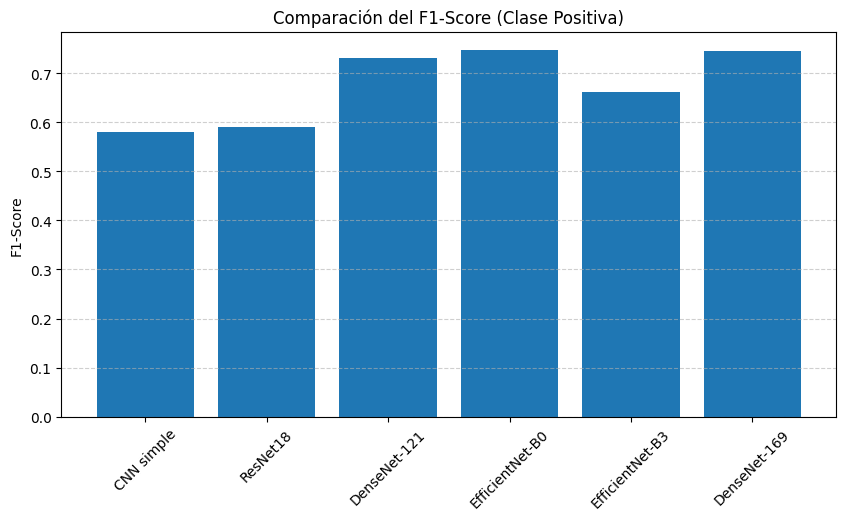

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.bar(df_results["Modelo"], df_results["F1_positivo"])
plt.title("Comparación del F1-Score (Clase Positiva)")
plt.ylabel("F1-Score")
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.show()


### Visualització del recall

- Gràfic de **barres** del *recall* de la classe positiva.
- Cada barra correspon a un **model**.
- Mostra la capacitat de cada model per **detectar casos positius**.
- Graella i rotació d’etiquetes per facilitar la comparació.


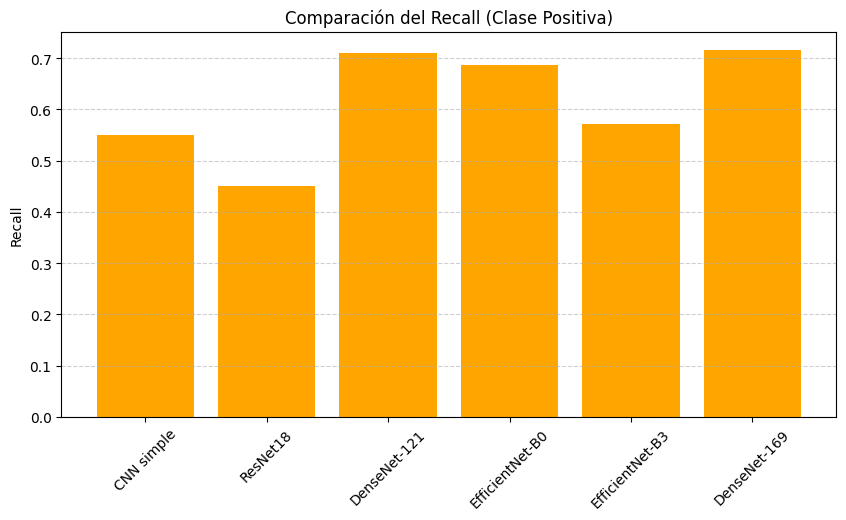

In [ ]:
plt.figure(figsize=(10,5))
plt.bar(df_results["Modelo"], df_results["Recall_positivo"], color="orange")
plt.title("Comparación del Recall (Clase Positiva)")
plt.ylabel("Recall")
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.show()


### Visualització de l’accuracy

- Gràfic de **barres** per comparar l’*accuracy* dels models.
- Cada barra representa un **model de classificació**.
- Permet observar el **rendiment global** de cada arquitectura.
- S’afegeix **graella** i rotació d’etiquetes per millorar la llegibilitat.


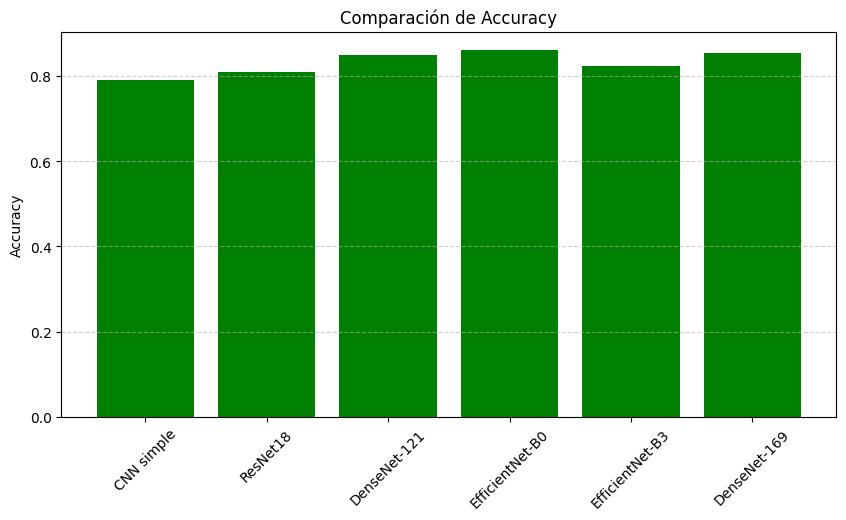

In [ ]:
plt.figure(figsize=(10,5))
plt.bar(df_results["Modelo"], df_results["Accuracy"], color="green")
plt.title("Comparación de Accuracy")
plt.ylabel("Accuracy")
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.show()


### Comparació conjunta de mètriques

- Gràfic de **barres agrupades** per comparar models.
- Es mostren **F1-score**, **Recall** i **Accuracy** simultàniament.
- Facilita la comparació **directa del rendiment global** entre arquitectures.
- Permet identificar els models amb millor **equilibri entre mètriques**.


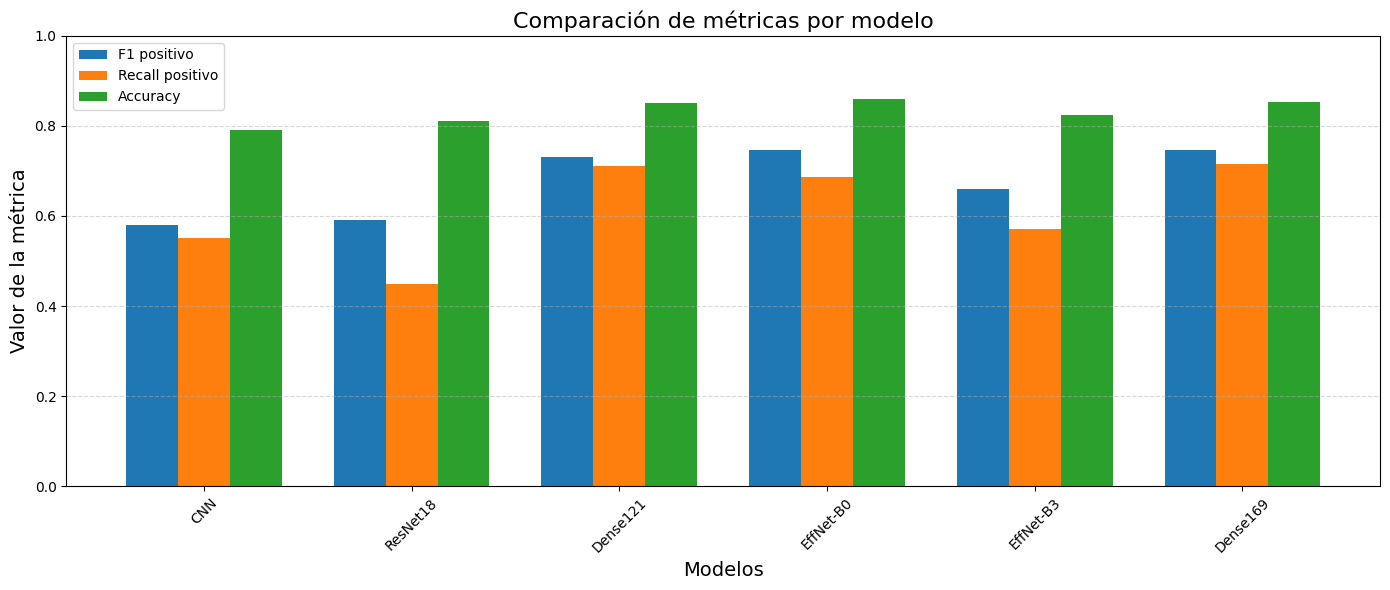

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Datos los 6 modelos
modelos = ["CNN", "ResNet18", "Dense121", "EffNet-B0", "EffNet-B3", "Dense169"]

f1 =     [0.58, 0.59, 0.73, 0.7465, 0.6605, 0.7454]
recall = [0.55, 0.45, 0.71, 0.6869, 0.5719, 0.7157]
acc =    [0.79, 0.81, 0.85, 0.8603, 0.8239, 0.8536]

# Configurar posiciones
x = np.arange(len(modelos))
width = 0.25 

plt.figure(figsize=(14, 6))

# Barras
plt.bar(x - width, f1, width, label='F1 positivo', color="#1f77b4")
plt.bar(x, recall, width, label='Recall positivo', color="#ff7f0e")
plt.bar(x + width, acc, width, label='Accuracy', color="#2ca02c")

# Estética
plt.title("Comparación de métricas por modelo", fontsize=16)
plt.xlabel("Modelos", fontsize=14)
plt.ylabel("Valor de la métrica", fontsize=14)
plt.xticks(x, modelos, rotation=45)
plt.ylim(0, 1.0)
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.legend()
plt.tight_layout()
plt.show()
